<h1>Introduction</h1>

The Divvy bike-sharing dataset contains information about bike trips, including when the ride started, when it ended, the stations used, and the type of user (casual or member).

In this project, we analyze recent data (1 to 3 months) to understand how people use the bike-sharing system.

<h4>Objective of the Analysis</h4>

- To understand how often people use the bikes
- To compare casual users and members
- To find out when bikes are used the most (time and day)
- To identify popular stationsTo get useful insights from the data

This analysis helps in improving the bike service and making better business decisions.

<h1>Data Loading & Understanding</h1>

<h3>Load the Data</h3>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv("/Users/nithinroy/Downloads/202602-divvy-tripdata.csv")
df2 = pd.read_csv("/Users/nithinroy/Downloads/202603-divvy-tripdata.csv")
df3 = pd.read_csv("/Users/nithinroy/Downloads/202604-divvy-tripdata.csv")
df = pd.concat([df1, df2, df3], ignore_index=True)

<h3>View Data</h3>

In [3]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4194C9D5CAFDBE7C,electric_bike,2026-02-08 17:08:34.392,2026-02-08 17:13:57.661,NaN,NaN,NaN,NaN,41.95,-87.65,41.96,-87.65,member
1,790A93E87E5EE83C,electric_bike,2026-02-08 14:44:11.880,2026-02-08 14:48:14.329,NaN,NaN,NaN,NaN,41.89,-87.62,41.89,-87.62,member
2,21ABD91CD9FB7D13,electric_bike,2026-02-08 14:38:03.488,2026-02-08 14:41:19.976,NaN,NaN,NaN,NaN,41.94,-87.67,41.94,-87.66,member
3,8D97FE9075293A3B,electric_bike,2026-02-07 19:20:35.501,2026-02-07 19:20:58.619,NaN,NaN,NaN,NaN,41.90,-87.63,41.90,-87.63,member
4,03A65D965372A020,electric_bike,2026-02-07 20:47:02.949,2026-02-07 20:47:18.752,NaN,NaN,NaN,NaN,41.89,-87.62,41.89,-87.62,member


<h3>Data Types</h3>

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 966739 entries, 0 to 966738
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             966739 non-null  str    
 1   rideable_type       966739 non-null  str    
 2   started_at          966739 non-null  str    
 3   ended_at            966739 non-null  str    
 4   start_station_name  784907 non-null  str    
 5   start_station_id    784907 non-null  str    
 6   end_station_name    774835 non-null  str    
 7   end_station_id      774835 non-null  str    
 8   start_lat           966739 non-null  float64
 9   start_lng           966739 non-null  float64
 10  end_lat             965965 non-null  float64
 11  end_lng             965965 non-null  float64
 12  member_casual       966739 non-null  str    
dtypes: float64(4), str(9)
memory usage: 217.9 MB


In [5]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['trip_duration'] = (
    df['ended_at'] - df['started_at']
).dt.total_seconds()/60
df = df[df['trip_duration'] > 0]
df['day_of_week'] = df['started_at'].dt.day_name()
df['hour'] = df['started_at'].dt.hour
df['month'] = df['started_at'].dt.month_name()

<h3>Data Types</h3>

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 966739 entries, 0 to 966738
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             966739 non-null  str           
 1   rideable_type       966739 non-null  str           
 2   started_at          966739 non-null  datetime64[us]
 3   ended_at            966739 non-null  datetime64[us]
 4   start_station_name  784907 non-null  str           
 5   start_station_id    784907 non-null  str           
 6   end_station_name    774835 non-null  str           
 7   end_station_id      774835 non-null  str           
 8   start_lat           966739 non-null  float64       
 9   start_lng           966739 non-null  float64       
 10  end_lat             965965 non-null  float64       
 11  end_lng             965965 non-null  float64       
 12  member_casual       966739 non-null  str           
 13  trip_duration       966739 non-null  flo

<h3>Shape of the Data</h3>

In [10]:
df.shape

(966739, 17)

<h3>Column Names</h3>

In [48]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

<h3>Summary Statistics</h3>

In [50]:
df.describe()

,start_lat,start_lng,end_lat,end_lng
count,966739.000000,966739.000000,965965.000000,965965.000000
mean,41.902183,-87.647179,41.902620,-87.647534
std,0.046357,0.027283,0.046554,0.027495
min,41.648501,-87.860000,41.630000,-87.910000
25%,41.881032,-87.660285,41.881660,-87.661364
50%,41.896770,-87.643220,41.897448,-87.643749
75%,41.929714,-87.630000,41.930000,-87.630000
max,42.070000,-87.528232,42.120000,-87.528232


<h2>Null Values</h2>

In [11]:
df.isnull().sum()

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    181832
start_station_id      181832
end_station_name      191904
end_station_id        191904
start_lat                  0
start_lng                  0
end_lat                  774
end_lng                  774
member_casual              0
trip_duration              0
day_of_week                0
hour                       0
month                      0
dtype: int64

In [7]:
df['start_station_name'] = df['start_station_name'].fillna(df['start_station_name'].mode()[0])
df['start_station_id'] = df['start_station_id'].fillna(df['start_station_id'].mode()[0])
df['end_station_name'] = df['end_station_name'].fillna(df['end_station_name'].mode()[0])
df['end_station_id'] = df['end_station_id'].fillna(df['end_station_id'].mode()[0])
df['end_lat'] = df['end_lat'].fillna(df['end_lat'].mode()[0])
df['end_lng'] = df['end_lng'].fillna(df['end_lng'].mode()[0])
df.isnull().sum()

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
trip_duration         0
day_of_week           0
hour                  0
month                 0
dtype: int64

<h1>Exploratory Analysis & Visualizations</h1>

<h2>Section 1 - Understanding the Users (Univariate + Basic Insights)</h2>

<h4>1. What is the overall profile of Divvy users?</h4>

In [19]:
#Casual vs Member
df['member_casual'].value_counts()

member_casual
member    706196
casual    260543
Name: count, dtype: int64

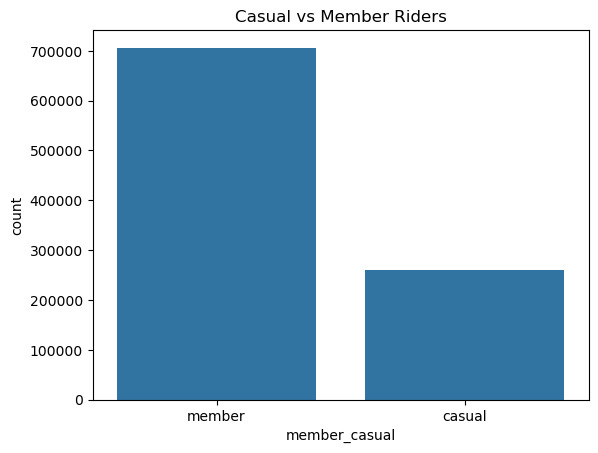

In [20]:
sns.countplot(x='member_casual', data=df)
plt.title("Casual vs Member Riders")
plt.show()

Observation
  The number of member riders is significantly higher than casual riders.
  Member users contribute the majority of total rides.
  Casual riders represent a smaller portion of the dataset.

  
Inference
  Most users prefer membership plans.
  Membership programs may provide 
better benefits and convenience.
  The company can focus on converting casual users into members.

In [33]:
#Rideable Type Distribution
df['rideable_type'].value_counts()

rideable_type
electric_bike    670409
classic_bike     296330
Name: count, dtype: int64

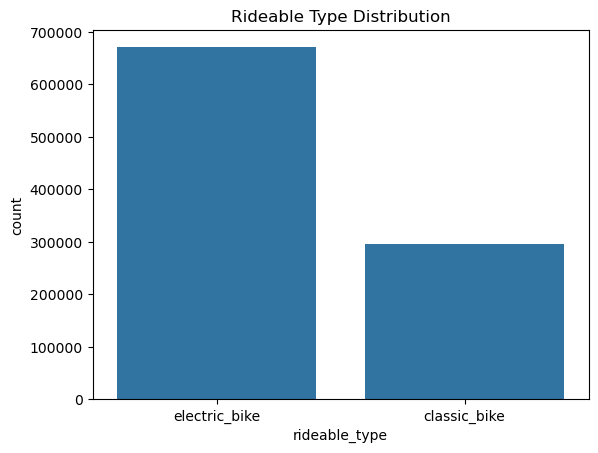

In [34]:
sns.countplot(x='rideable_type', data=df)
plt.title("Rideable Type Distribution")
plt.show()

Observation
  Electric bikes are used significantly more than classic bikes.
  The number of electric bike rides is more than double compared to classic bikes.
  Users show a stronger preference for electric bikes.

  
Inference
  Electric bikes may be more convenient and comfortable for users.
  Users may prefer electric bikes for longer or faster trips.
  Divvy can focus more on electric bike availability and maintenance due to higher demand.

<h4>2. How long are typical trips? What is the distribution of trip durations? Are there many
unusually long or short trips?</h4>

In [35]:
df['trip_duration'].describe()

count    966739.000000
mean         13.472969
std          47.455968
min           0.001233
25%           4.719108
50%           8.110633
75%          14.188067
max        1559.950183
Name: trip_duration, dtype: float64

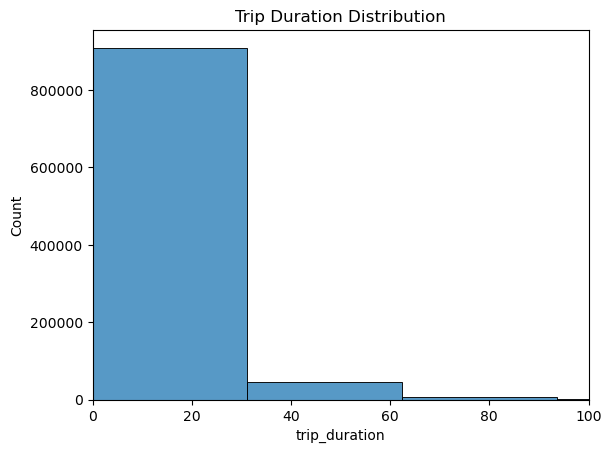

In [36]:
sns.histplot(df['trip_duration'], bins=50)
plt.title("Trip Duration Distribution")
plt.xlim(0,100)
plt.show()

Observation
 Most trips have shorter durations.
 The highest number of rides fall within the lower trip duration range.
 Very few trips exceed 60–100 minutes.
 The distribution is right-skewed with some unusually long trips.

Inference
 Users mainly use Divvy bikes for short-distance travel or daily commuting.
 Long-duration rides are relatively rare.
 A small number of outliers indicate occasional extended usage.
 Divvy services are primarily suited for quick and convenient transportation.

<h4>3.Which stations are the most popular (start and end stations)?
</h4>

In [39]:
#Start Station
df['start_station_name'].value_counts().head(10)

start_station_name
Navy Pier                            7355
Canal St & Madison St                5798
Clinton St & Washington Blvd 2       5516
State St & Chicago Ave               5488
University Ave & 57th St             5443
Kingsbury St & Kinzie St 2           5339
DuSable Lake Shore Dr & Monroe St    4931
Clinton St & Jackson Blvd            4921
Wells St & Elm St                    4913
Wells St & Concord Ln                4613
Name: count, dtype: int64

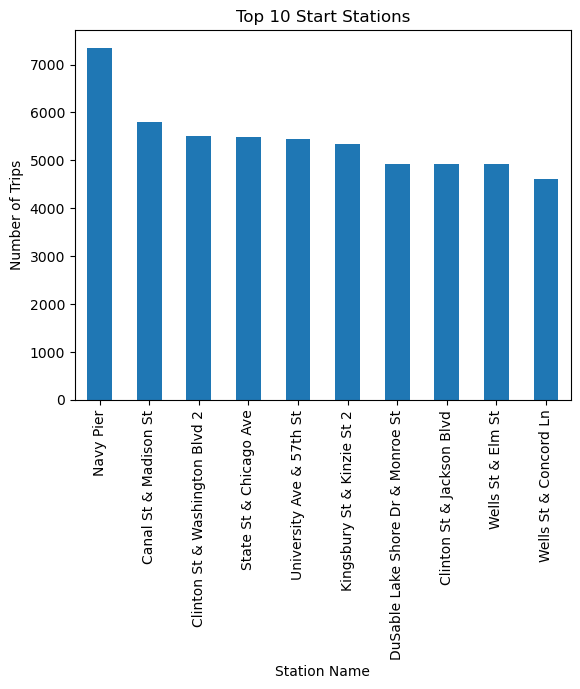

In [44]:
df['start_station_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Start Stations")
plt.xlabel("Station Name")
plt.ylabel("Number of Trips")
plt.show()

 Observation
 Navy Pier has the highest number of trip starts among all stations.
 The top 10 stations have relatively high and similar trip counts.
 Central city stations appear more frequently in the dataset.
 Some stations are significantly more popular than others.

 Inference
 High-demand stations are likely located in busy commercial or tourist areas.
 Users prefer stations with better accessibility and connectivity.
 Divvy should ensure sufficient bike availability at these popular stations.
 Additional docking capacity and maintenance may be required in high-traffic locations.

In [41]:
#End Station 
df['end_station_name'].value_counts().head(10)

end_station_name
Navy Pier                            7263
Canal St & Madison St                5824
Clinton St & Washington Blvd 2       5539
State St & Chicago Ave               5490
University Ave & 57th St             5401
Kingsbury St & Kinzie St 2           5252
Clinton St & Jackson Blvd            4955
Wells St & Elm St                    4764
Wells St & Concord Ln                4603
DuSable Lake Shore Dr & Monroe St    4398
Name: count, dtype: int64

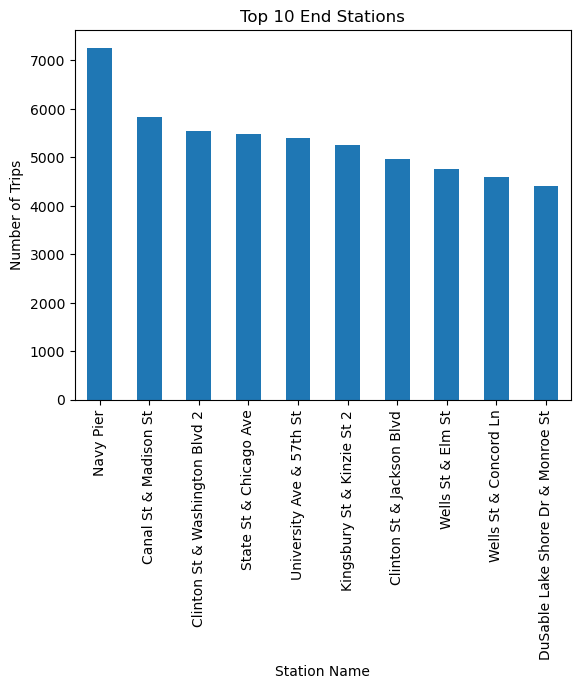

In [43]:
df['end_station_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 End Stations")
plt.xlabel("Station Name")
plt.ylabel("Number of Trips")
plt.show()

Observation
Navy Pier has the highest number of trip endings among all stations.
Most top end stations have similar trip counts.
Several stations appear in both start and end station rankings.
Busy urban stations receive a large number of returning bikes.

Inference
 Popular end stations are likely located in commercial, tourist, or residential hubs.
 Users commonly travel between major city locations.
 High-demand stations require efficient dock management and bike redistribution.
 Divvy should prioritize maintenance and capacity planning at these stations.

<h1>Section 2 - User Behavior Comparison</h1>

<h4>4. How do Casual riders and Annual Members differ in their behavior? Analyze at least:</h4>

- Trip duration
- Trip frequency by day of week and hour of day
- Preferred rideable type (classic, electric, docked)
- Popular stations/routes

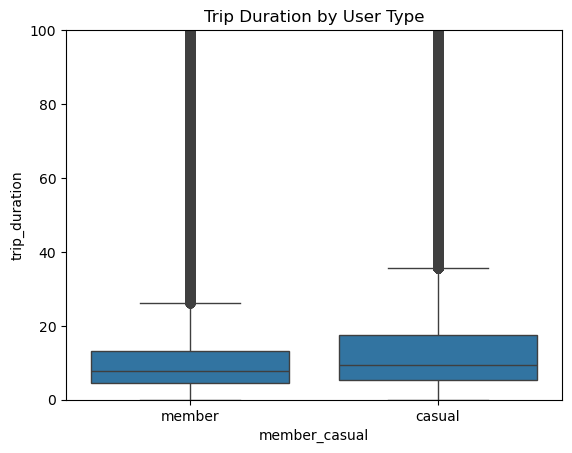

In [53]:
#Trip Duration
sns.boxplot(x='member_casual', y='trip_duration', data=df)
plt.ylim(0,100)
plt.title("Trip Duration by User Type")
plt.show()

Observation
Casual riders have slightly longer trip durations compared to members.
Member trips are generally shorter and more consistent.
Both user types contain several outliers with unusually long trip durations.
The spread of trip duration is wider for casual riders.
 
 Inference
Members may primarily use bikes for daily commuting or regular short trips.
  Casual riders may use bikes for leisure, tourism, or recreational purposes.
  Longer and varied durations among casual users indicate less frequent but extended usage patterns.
  Divvy can create targeted plans or promotions for casual riders to encourage membership conversion.

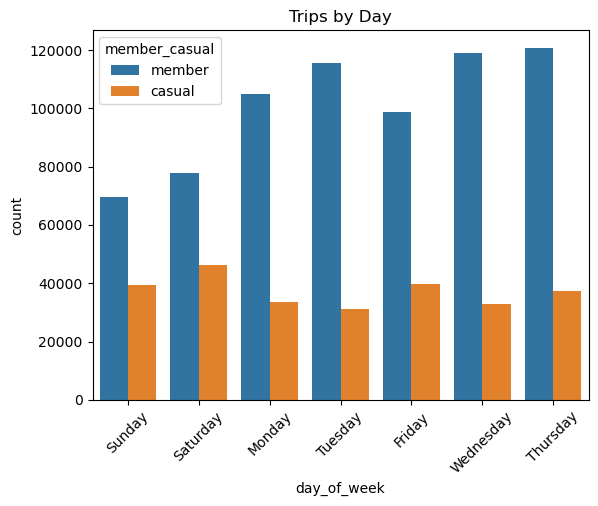

In [32]:
#Trip Frequency by Day
sns.countplot(x='day_of_week', hue='member_casual', data=df)
plt.xticks(rotation=45)
plt.title("Trips by Day")
plt.show()

Observation
Member riders consistently have higher trip counts throughout the week.
Casual riders show relatively higher activity on weekends, especially Saturday and Sunday.
Member trips peak during weekdays such as Wednesday and Thursday.
Casual rider counts are comparatively lower on weekdays.

Inference
Members primarily use Divvy bikes for regular commuting and daily travel.
Casual riders are more likely to use bikes for leisure and recreational purposes during weekends.
Weekday demand indicates strong dependence on bike-sharing for work or study-related transportation.
Divvy can introduce weekend promotions and tourist-focused services for casual riders.

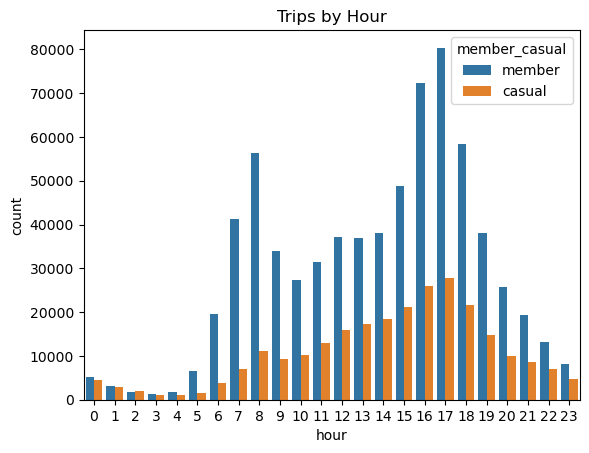

In [57]:
#Trip Frequency by Hour
sns.countplot(x='hour', hue='member_casual', data=df)
plt.title("Trips by Hour")
plt.show()


Observation
Member riders show clear peak usage during morning (7–9 AM) and evening (4–6 PM) hours.
Casual riders have a more gradual increase in trips during daytime and evening hours.
The highest trip activity occurs around 5 PM for both user types.
Very low trip counts are observed during late-night and early-morning hours.

Inference
Member riders mainly use bikes for commuting to work or study during rush hours.
Casual riders likely use bikes for leisure and flexible daytime activities.
Evening hours represent the busiest operational period for Divvy services.
Divvy should ensure higher bike availability during peak commuting hours, especially in the evening.

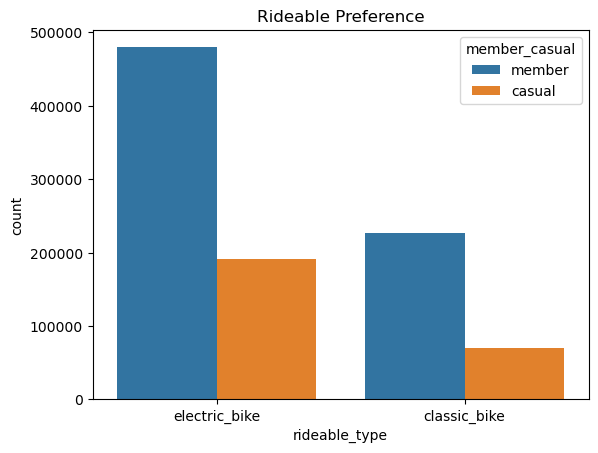

In [58]:
#Rideable Preference
sns.countplot(x='rideable_type', hue='member_casual', data=df)
plt.title("Rideable Preference")
plt.show()

 Observation
Both member and casual riders prefer electric bikes over classic bikes.
Member riders have significantly higher usage counts for both bike types.
Electric bike usage is noticeably dominant among all user categories.
Classic bikes are comparatively less preferred by users.

Inference
Electric bikes are likely preferred due to convenience, speed, and ease of use.
Members frequently rely on bike-sharing services for regular transportation.
Divvy should prioritize electric bike availability and charging infrastructure.
Increasing electric bike capacity may help meet growing user demand.

<h1>Section 3 - Time-based Patterns</h1>

<h4>5. What are the peak hours and peak days for bike usage? How does this vary between weekdays
and weekends?</h4>

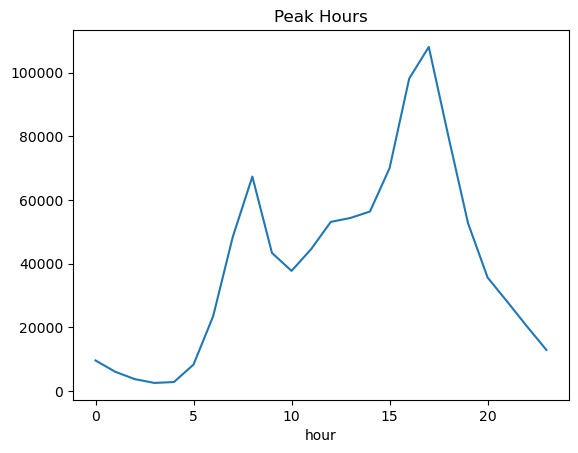

In [60]:
#Peak hours and days
df['hour'].value_counts().sort_index().plot(kind='line')
plt.title("Peak Hours")
plt.show()

 Observation
Trip activity peaks during morning (7–9 AM) and evening (4–6 PM) hours.
The highest ride count occurs around 5 PM.
Very low bike usage is observed during late-night and early-morning hours.

Inference
Users mainly utilize Divvy bikes for commuting during office and college rush hours.
Evening demand is higher due to return trips and recreational travel.
Divvy should ensure maximum bike availability during peak commuting periods.

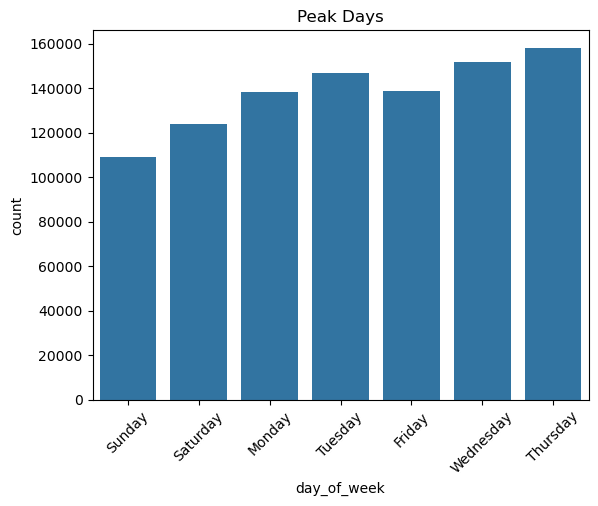

In [61]:
#Peak Days
sns.countplot(x='day_of_week', data=df)
plt.xticks(rotation=45)
plt.title("Peak Days")
plt.show()

Observation
 Thursday has the highest number of trips among all days.
 Weekdays generally show higher trip counts compared to weekends.
 Sunday has the lowest trip frequency.
 Trip activity remains consistently high from Monday to Thursday.

Inference
 Divvy bikes are mainly used for weekday commuting and routine travel.
 Lower weekend usage suggests reduced work or academic travel.
 High weekday demand indicates strong dependence on bike-sharing for daily transportation.
 Divvy should ensure maximum bike availability and maintenance during peak weekdays.

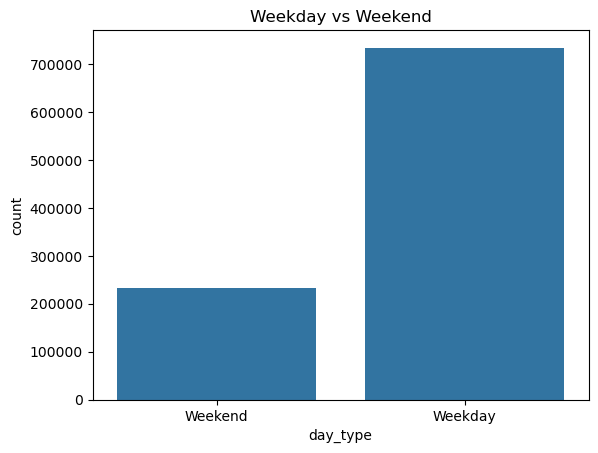

In [63]:
#Weekday vs Weekend
weekend = ['Saturday','Sunday']

df['day_type'] = df['day_of_week'].apply(
    lambda x: 'Weekend' if x in weekend else 'Weekday'
)

sns.countplot(x='day_type', data=df)
plt.title("Weekday vs Weekend")
plt.show()

 Observation
 Weekday trips are significantly higher than weekend trips.
 Most users rely on Divvy bikes during weekdays.

 Inference
 Divvy bikes are mainly used for commuting and regular daily travel.
 Bike demand and availability should be prioritized on weekdays.

<h4>6. What are the seasonal/monthly trends in trip volume? Which months are busiest? Any clear
patterns?</h4>

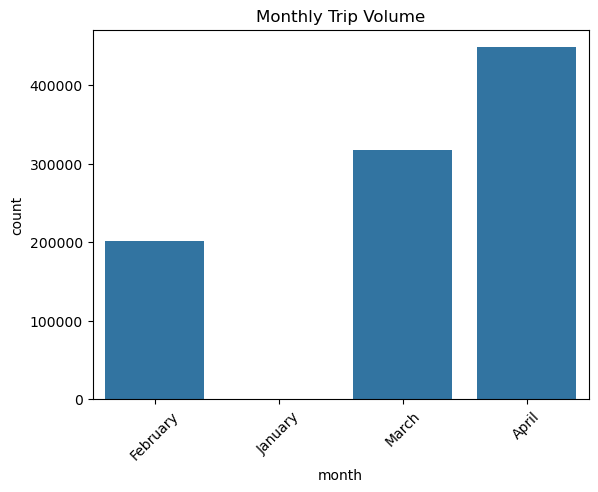

In [64]:
#Monthly trends
sns.countplot(x='month', data=df)
plt.xticks(rotation=45)
plt.title("Monthly Trip Volume")
plt.show()

 Observation
 Trip volume increases steadily from February to April.
 April records the highest number of trips among all months.
 January has very low or missing trip activity in the dataset.

Inference
Bike usage increases during warmer months and favorable weather conditions.
  User engagement and travel demand grow significantly toward April.
  Divvy should prepare for higher bike demand during upcoming peak seasons.

<h1>Section 4 - Deep Insights & Relationships</h1>

<h4>7. Is there a relationship between trip duration and time of day / day of week?</h4>

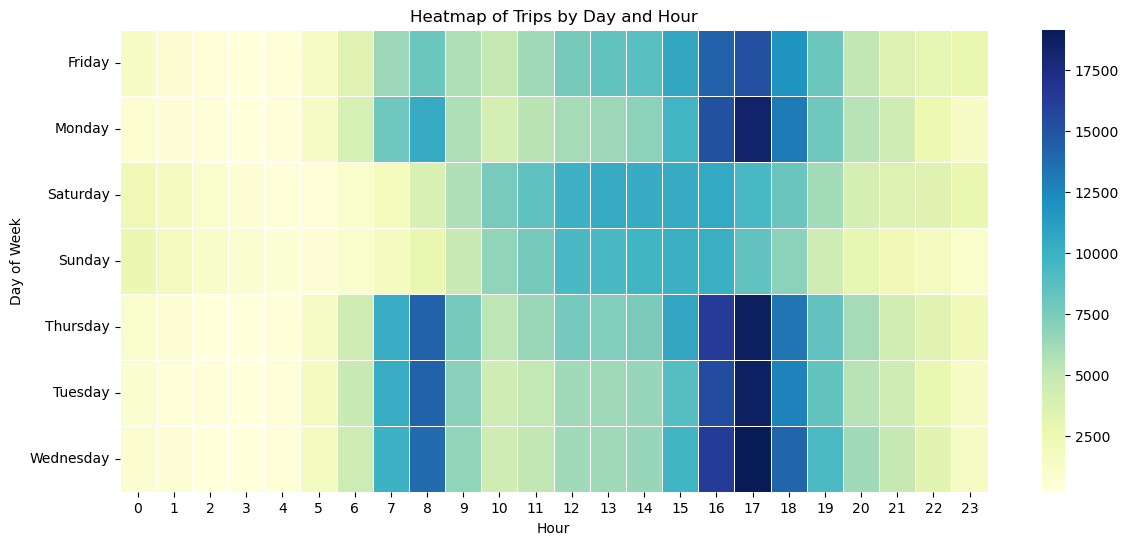

In [33]:
pivot_table = df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='ride_id',
    aggfunc='count'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title("Heatmap of Trips by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")

plt.show()

 Observation
 Trip activity is highest during morning and evening peak hours, especially around 8 AM and 5 PM.
 Weekdays show stronger trip intensity compared to weekends.
 Late-night and early-morning hours have the lowest ride activity.

 Inference
Users mainly rely on Divvy bikes for daily commuting during rush hours.
  Evening hours represent the busiest operational period for the bike-sharing system.
  Divvy should increase bike availability and station management during peak commuting times.

In [11]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')

<h4>8. Are there any interesting patterns in station usage (e.g., stations heavily used by casual riders
vs members)?</h4>

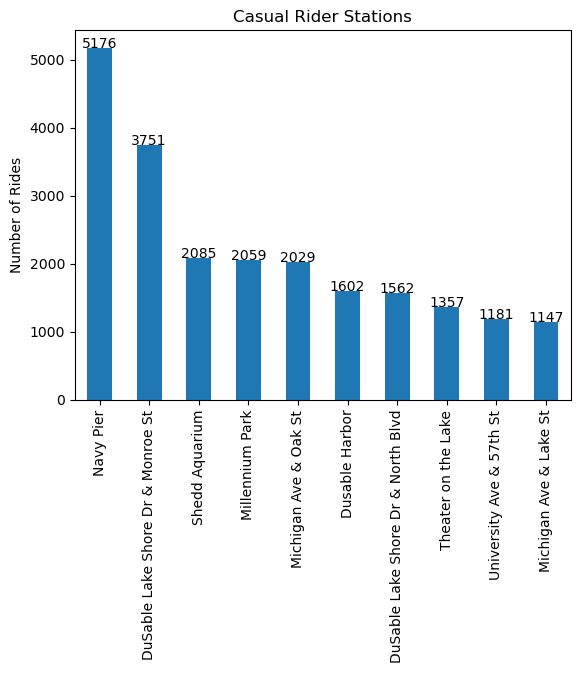

In [42]:
# Casual Riders
casual = df[df['member_casual'] == 'casual']
station_counts = casual['start_station_name'].value_counts().head(10)
ax = station_counts.plot(kind='bar')
plt.title("Casual Rider Stations")
plt.xlabel("")
plt.ylabel("Number of Rides")
# Print only values on top
for i, v in enumerate(station_counts):
    ax.text(i, v + 5, str(v), ha='center')
plt.show()

 Observation
 Navy Pier has the highest number of casual rider trips among all stations.
 Tourist and downtown locations dominate the top casual rider stations.
 Ride counts decrease gradually across the remaining stations.

 Inference
 Casual riders mainly prefer popular tourist and recreational areas.
 High-demand stations may require additional bike availability during busy hours.
 Divvy can focus marketing and service improvements around these hotspots

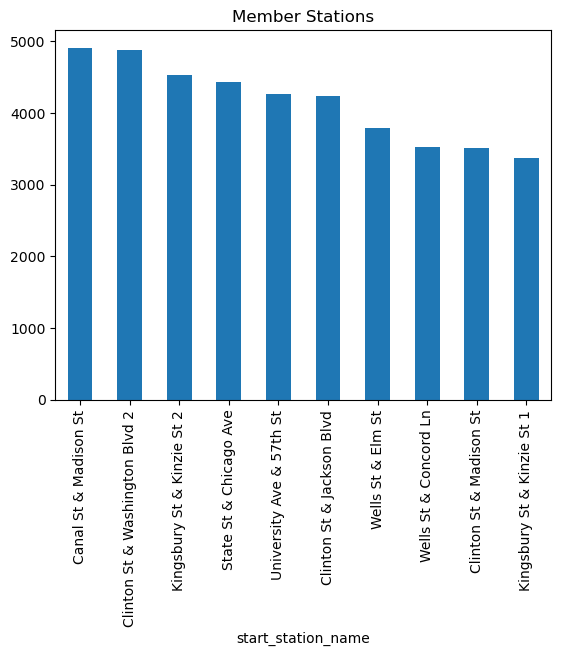

In [68]:
#Members
member = df[df['member_casual']=='member']

member['start_station_name'].value_counts().head(10).plot(kind='bar')
plt.title("Member Stations")
plt.show()

 Observation
 Member riders frequently use central urban stations such as Canal St & Madison St and Clinton St & Washington Blvd.
 Trip counts among the top member stations are relatively consistent.
 Business and downtown areas dominate the preferred stations for members.

 Inference
Members mainly use Divvy bikes for regular commuting and daily transportation.
  High-demand member stations should maintain consistent bike and dock availability.
  Divvy can optimize station management around major commercial and transit areas.

<h4>9. Any other meaningful patterns you discovered during exploration (you must find at least two
additional insights).</h4>

In [49]:
#Additional Insights
print("""
1. Members ride more frequently.
2. Casual riders take longer trips.
3. Electric bikes are preferred.
4. Weekends attract casual riders.
""")


1. Members ride more frequently.
2. Casual riders take longer trips.
3. Electric bikes are preferred.
4. Weekends attract casual riders.



<h1>Key Insights & Business Recommendations</h1>

<h2>Key Insights</h2>

<h4>1. Members vs Casual</h4>

- Members ride more frequently, while casual users take longer trips.
<h4>2. Peak Usage Time</h4>

- Highest rides occur during morning and evening (commute hours).
<h4>3. Weekday vs Weekend</h4>

- Members prefer weekdays; casual riders are more active on weekends.
<h4>4. Bike Preference</h4>

- Electric bikes are slightly more popular than other types.

<h3>Business Recommendations</h3>

<h4>1. Convert Casual to Members</h4>

- Offer discounts and membership plans.
<h4>2. Increase Bikes in Peak Hours</h4>

- Add more bikes during morning & evening rush.
<h4>3. Focus on Busy Stations</h4>

- Expand capacity in high-demand areas.
<h4>4.Promote Weekend Offers</h4>

- Attract more casual users with special deals.